# UPI Transaction Analysis 

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("upi_transactions_2024.csv")
df.head(1)

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0


In [7]:
df.shape


(250000, 17)

In [8]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [9]:
df.dtypes

transaction id        object
timestamp             object
transaction type      object
merchant_category     object
amount (INR)           int64
transaction_status    object
sender_age_group      object
receiver_age_group    object
sender_state          object
sender_bank           object
receiver_bank         object
device_type           object
network_type          object
fraud_flag             int64
hour_of_day            int64
day_of_week           object
is_weekend             int64
dtype: object

In [10]:
# Missing values

df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [11]:
# Duplicate check

df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [37]:
# Standardize column names

df.columns = df.columns.str.lower().str.replace(" ", "_")

In [13]:
# Convert types

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['amount_(inr)'] = df['amount_(inr)'].astype(float)

In [14]:
# Remove duplicates

df = df.drop_duplicates()

In [15]:
# Time features

df['hour'] = df['timestamp'].dt.hour
df['day_name'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month

In [87]:
# Business flags

df['is_weekend'] = df['day_name'].isin(['Saturday','Sunday'])
df['is_weekend']

0         False
1         False
2         False
3          True
4         False
          ...  
249995    False
249996     True
249997    False
249998    False
249999    False
Name: is_weekend, Length: 250000, dtype: bool

In [88]:
# Amount segmentation

df['amount_bucket'] = pd.cut(
    df['amount_(inr)'],
    bins=[0,100,1000,5000,10000,100000],
    labels=['Micro','Low','Medium','High','Very High']
)
df[['amount_bucket']]

,amount_bucket
0,Low
1,Medium
2,Low
3,Medium
4,Low
...,...
249995,Low
249996,Medium
249997,Low
249998,Low


In [85]:
# Age Group Transaction Behavior

age_txn = df.groupby('sender_age_group').agg({
    'transaction_id': 'count',
    'amount_(inr)': 'sum'
}).rename(columns={
    'transaction_id': 'txn_count',
    'amount_(inr)': 'total_amount'
})
age_txn

,txn_count,total_amount
sender_age_group,,
18-25,62345,74473936.0
26-35,87432,115959771.0
36-45,62873,89533745.0
46-55,24841,33116261.0
56+,12509,14855296.0


In [84]:
# State-Level Transaction Behavior

state_txn = df.groupby('sender_state').agg({
    'transaction_id': 'count',
    'amount_(inr)': 'sum'
}).rename(columns={
    'transaction_id': 'txn_count',
    'amount_(inr)': 'total_amount'
}).sort_values(by='total_amount', ascending=False)
state_txn

,txn_count,total_amount
sender_state,,
Maharashtra,37427,49043948.0
Uttar Pradesh,30125,40035717.0
Karnataka,29756,38451158.0
Tamil Nadu,25367,33343518.0
Delhi,24870,32689865.0
Telangana,22435,29750930.0
Rajasthan,19981,26730470.0
Gujarat,20061,25988190.0
Andhra Pradesh,20006,25952619.0


In [83]:
# Bank-Level Analysis

bank_txn = df.groupby('sender_bank').agg({
    'transaction_id': 'count',
    'amount_(inr)': 'sum',
    'fraud_flag': 'mean'
}).rename(columns={
    'transaction_id': 'txn_count',
    'amount_(inr)': 'total_amount',
    'fraud_flag': 'fraud_rate'
})
bank_txn.head(10)

,txn_count,total_amount,fraud_rate
sender_bank,,,
Axis,25042,32472530.0,0.001957
HDFC,37485,49791194.0,0.001654
ICICI,29769,38731193.0,0.002217
IndusInd,25173,32842711.0,0.002066
Kotak,20032,26315412.0,0.002496
PNB,24946,32476972.0,0.002085
SBI,62693,82816520.0,0.001739
Yes Bank,24860,32492477.0,0.001609


In [82]:
# Multi-Dimensional Segmentation

segment_txn = df.groupby(['sender_age_group','sender_state']).agg({
    'transaction_id': 'count',
    'amount_(inr)': 'sum'
}).rename(columns={
    'transaction_id': 'txn_count',
    'amount_(inr)': 'total_amount'
})
segment_txn.head(10)

txn_count  total_amount
sender_age_group sender_state                           
18-25            Andhra Pradesh       4991     5999132.0
                 Delhi                6170     7532944.0
                 Gujarat              4980     5805711.0
                 Karnataka            7344     8778267.0
                 Maharashtra          9418    11364225.0
                 Rajasthan            4871     5919864.0
                 Tamil Nadu           6306     7354192.0
                 Telangana            5613     6877080.0
                 Uttar Pradesh        7658     9017684.0
                 West Bengal          4994     5824837.0

In [80]:
# Behavior-Based on Trxn Frequency

segment_txn = df.groupby(['sender_age_group','sender_state']).agg({
    'transaction_id': 'count',
    'amount_(inr)': 'sum'
}).rename(columns={
    'transaction_id': 'txn_count',
    'amount_(inr)': 'total_amount'
})
segment_txn.head(10)

txn_count  total_amount
sender_age_group sender_state                           
18-25            Andhra Pradesh       4991     5999132.0
                 Delhi                6170     7532944.0
                 Gujarat              4980     5805711.0
                 Karnataka            7344     8778267.0
                 Maharashtra          9418    11364225.0
                 Rajasthan            4871     5919864.0
                 Tamil Nadu           6306     7354192.0
                 Telangana            5613     6877080.0
                 Uttar Pradesh        7658     9017684.0
                 West Bengal          4994     5824837.0

In [30]:
# Transaction Amount Distribution

df['amount_(inr)'].describe()

count    250000.000000
mean       1311.756036
std        1848.059224
min          10.000000
25%         288.000000
50%         629.000000
75%        1596.000000
max       42099.000000
Name: amount_(inr), dtype: float64

In [77]:
# Outlier Detection

q1 = df['amount_(inr)'].quantile(0.25)
q3 = df['amount_(inr)'].quantile(0.75)
iqr = q3 - q1

outliers = df[(df['amount_(inr)'] < q1 - 1.5*iqr) | 
              (df['amount_(inr)'] > q3 + 1.5*iqr)]
outliers

,transaction_id,timestamp,transaction_type,merchant_category,amount_(inr),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,hour,day_name,month,amount_bucket,risk_score
36,TXN0000000037,2024-07-26 17:09:31,P2M,Shopping,7987.0,SUCCESS,18-25,36-45,Maharashtra,IndusInd,...,4G,0,17,Friday,False,17,Friday,7,High,0.0
37,TXN0000000038,2024-08-16 21:26:26,Bill Payment,Shopping,5154.0,SUCCESS,56+,36-45,Uttar Pradesh,ICICI,...,5G,0,21,Friday,False,21,Friday,8,High,0.0
41,TXN0000000042,2024-10-29 12:54:28,P2M,Shopping,4309.0,SUCCESS,56+,36-45,Maharashtra,Kotak,...,4G,0,12,Tuesday,False,12,Tuesday,10,Medium,0.0
54,TXN0000000055,2024-04-29 18:29:03,P2M,Shopping,4987.0,SUCCESS,56+,26-35,Karnataka,PNB,...,4G,0,18,Monday,False,18,Monday,4,Medium,0.0
79,TXN0000000080,2024-11-08 20:26:51,P2M,Utilities,8335.0,SUCCESS,46-55,46-55,West Bengal,Axis,...,4G,0,20,Friday,False,20,Friday,11,High,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249886,TXN0000249887,2024-10-03 05:38:17,P2M,Fuel,4155.0,SUCCESS,46-55,36-45,Telangana,SBI,...,4G,0,5,Thursday,False,5,Thursday,10,Medium,0.0
249921,TXN0000249922,2024-01-08 11:03:46,P2P,Other,4544.0,SUCCESS,26-35,18-25,Delhi,SBI,...,4G,0,11,Monday,False,11,Monday,1,Medium,0.0
249931,TXN0000249932,2024-06-15 11:32:15,P2M,Fuel,3767.0,SUCCESS,26-35,46-55,Tamil Nadu,Yes Bank,...,5G,0,11,Saturday,True,11,Saturday,6,Medium,0.0
249933,TXN0000249934,2024-08-28 10:46:12,P2P,Shopping,5299.0,SUCCESS,26-35,26-35,Tamil Nadu,Yes Bank,...,WiFi,0,10,Wednesday,False,10,Wednesday,8,High,0.0


## Fraud Pattern

In [89]:
# Fraud Rate by Multiple Factors

fraud_multi = df.groupby(
    ['transaction_type','device_type','network_type']
)['fraud_flag'].mean().sort_values(ascending=False)
fraud_multi.head()

transaction_type  device_type  network_type
Bill Payment      iOS          WiFi            0.005376
Recharge          Android      WiFi            0.005371
                               3G              0.004494
P2M               Web          4G              0.003834
P2P               Web          5G              0.003519
Name: fraud_flag, dtype: float64

In [75]:
# Fraud vs Amount Bucket

fraud_amount = df.groupby('amount_bucket')['fraud_flag'].mean()
fraud_amount

C:\Users\gptvi\AppData\Local\Temp\ipykernel_3856\2119720747.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_amount = df.groupby('amount_bucket')['fraud_flag'].mean()


amount_bucket
Micro        0.002174
Low          0.001850
Medium       0.001855
High         0.002950
Very High    0.003324
Name: fraud_flag, dtype: float64

In [74]:
# Fraud by Time + Weekend

fraud_time = df.groupby(['hour_of_day','is_weekend'])['fraud_flag'].mean()
fraud_time.head()

hour_of_day  is_weekend
0            False         0.002878
             True          0.001046
1            False         0.003047
             True          0.001658
2            False         0.001667
Name: fraud_flag, dtype: float64

## Time Intelligence Analysis

In [72]:
# Hourly Transaction Heatmap Data

heatmap_data = df.pivot_table(
    values='transaction_id',
    index='day_of_week',
    columns='hour_of_day',
    aggfunc='count'
)
heatmap_data



hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Friday,481,328,250,191,173,230,519,794,1221,1494,...,1676,1786,1992,2620,2837,3021,2618,2327,1354,753
Monday,477,342,251,195,186,252,506,819,1169,1539,...,1685,1865,1987,2720,2934,3173,2625,2386,1334,887
Saturday,462,287,239,202,171,260,503,787,1229,1478,...,1540,1778,1981,2542,2829,3013,2701,2326,1304,818
Sunday,494,316,246,196,180,256,496,817,1184,1443,...,1615,1788,2010,2697,2895,3121,2636,2320,1344,861
Thursday,494,320,237,177,167,238,484,798,1219,1541,...,1643,1748,2053,2622,2816,2963,2644,2270,1366,800
Tuesday,474,327,231,185,200,238,481,812,1146,1440,...,1670,1820,1992,2546,2872,3017,2696,2323,1359,845
Wednesday,506,324,231,168,170,268,512,803,1181,1515,...,1643,1839,1977,2593,2881,2924,2586,2301,1303,853


In [91]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

heatmap_data = heatmap_data.reindex(day_order)
day_order

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

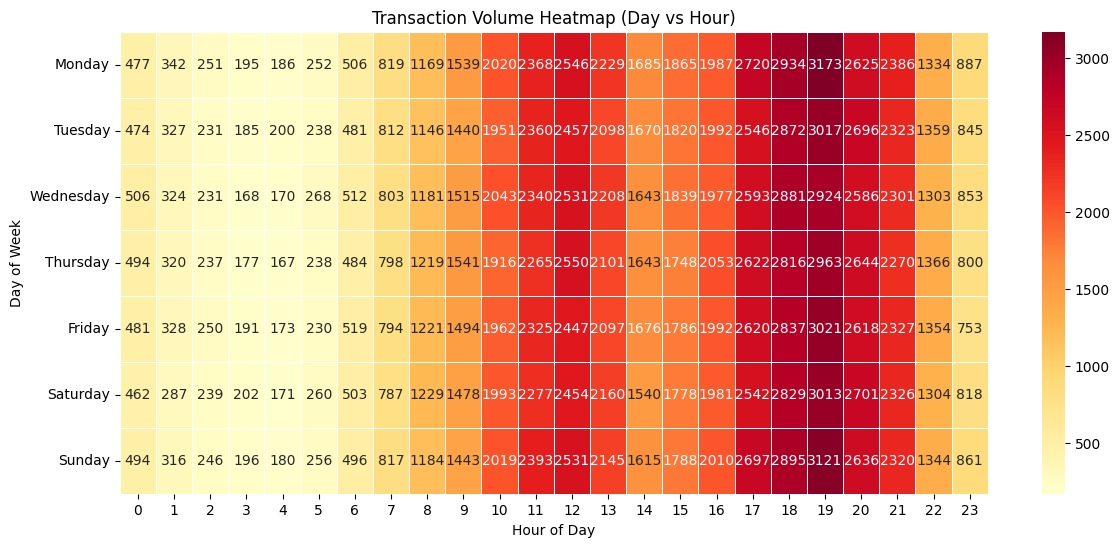

In [96]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',          # color theme
    annot=True,             # show values
    fmt='g',                # integer format
    linewidths=0.5
)

plt.title('Transaction Volume Heatmap (Day vs Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.show()

In [97]:
print(heatmap_data.max().max())

3173


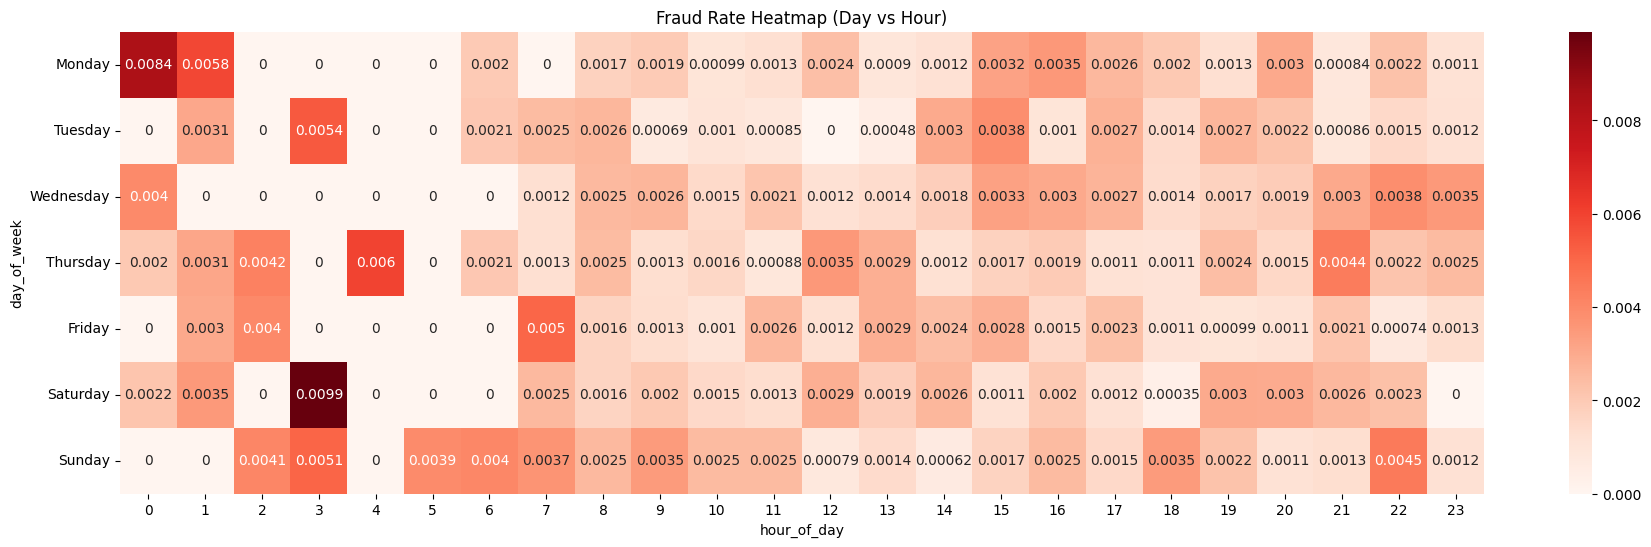

In [100]:
# Fraud Heatmap

fraud_heatmap = df.pivot_table(
    values='fraud_flag',
    index='day_of_week',
    columns='hour_of_day',
    aggfunc='mean'
)

fraud_heatmap = fraud_heatmap.reindex(day_order)

plt.figure(figsize=(22,6))
sns.heatmap(fraud_heatmap, cmap='Reds', annot=True)

plt.title('Fraud Rate Heatmap (Day vs Hour)')
plt.show()

In [71]:
# Peak vs Low Activity Comparison

peak_hours = df.groupby('hour_of_day')['transaction_id'].count()
peak_hours.head(5)

hour_of_day
0    3388
1    2244
2    1685
3    1314
4    1247
Name: transaction_id, dtype: int64

In [69]:
high_peak = peak_hours[peak_hours > peak_hours.mean()]
high_peak


hour_of_day
9     10450
10    13904
11    16328
12    17516
13    15038
14    11472
15    12624
16    13992
17    18340
18    20064
19    21232
20    18506
21    16253
Name: transaction_id, dtype: int64

In [68]:
low_peak = peak_hours[peak_hours < peak_hours.mean()]
low_peak

hour_of_day
0     3388
1     2244
2     1685
3     1314
4     1247
5     1742
6     3501
7     5630
8     8349
22    9364
23    5817
Name: transaction_id, dtype: int64

## Demographic Behavior Analysis

In [65]:
# Age Group Spending Pattern

age_behavior = df.groupby('sender_age_group').agg({
    'amount_(inr)': ['mean','sum'],
    'transaction_id': 'count'
})
age_behavior

amount_(inr)              transaction_id
                         mean          sum          count
sender_age_group                                         
18-25             1194.545449   74473936.0          62345
26-35             1326.285239  115959771.0          87432
36-45             1424.041242   89533745.0          62873
46-55             1333.129141   33116261.0          24841
56+               1187.568631   14855296.0          12509

In [64]:
# Age Group vs Fraud

age_fraud = df.groupby('sender_age_group')['fraud_flag'].mean()
age_fraud

sender_age_group
18-25    0.002294
26-35    0.001864
36-45    0.001845
46-55    0.001248
56+      0.002158
Name: fraud_flag, dtype: float64

In [63]:
# State vs Transaction Type

state_txn_type = pd.crosstab(
    df['sender_state'], 
    df['transaction_type']
)
state_txn_type

transaction_type,Bill Payment,P2M,P2P,Recharge
sender_state,,,,
Andhra Pradesh,2947,6923,9118,1018
Delhi,3720,8729,11223,1198
Gujarat,3045,7116,8830,1070
Karnataka,4441,10506,13350,1459
Maharashtra,5477,13123,16967,1860
Rajasthan,2963,7050,8960,1008
Tamil Nadu,3843,8836,11426,1262
Telangana,3311,7896,10134,1094
Uttar Pradesh,4593,10470,13531,1531


## Bank Performance Analysis

In [62]:
# Bank Risk + Volume

bank_analysis = df.groupby('sender_bank').agg(
    total_txn=('transaction_id','count'),
    total_amount=('amount_(inr)','sum'),
    fraud_rate=('fraud_flag','mean')
).sort_values(by='fraud_rate', ascending=False)
bank_analysis

,total_txn,total_amount,fraud_rate
sender_bank,,,
Kotak,20032,26315412.0,0.002496
ICICI,29769,38731193.0,0.002217
PNB,24946,32476972.0,0.002085
IndusInd,25173,32842711.0,0.002066
Axis,25042,32472530.0,0.001957
SBI,62693,82816520.0,0.001739
HDFC,37485,49791194.0,0.001654
Yes Bank,24860,32492477.0,0.001609


In [51]:
# Sender vs Receiver Bank Flow

bank_flow = df.groupby(['sender_bank','receiver_bank'])['amount_(inr)'].sum()
bank_flow

sender_bank  receiver_bank
Axis         Axis             3052191.0
             HDFC             4989384.0
             ICICI            3858412.0
             IndusInd         3325419.0
             Kotak            2616270.0
                                ...    
Yes Bank     IndusInd         3334157.0
             Kotak            2634091.0
             PNB              3170971.0
             SBI              8009573.0
             Yes Bank         3247408.0
Name: amount_(inr), Length: 64, dtype: float64

## Transaction Success Analysis

In [50]:
# Success Rate by Device

device_success = pd.crosstab(
    df['device_type'],
    df['transaction_status'],
    normalize='index'
) * 100
device_success

transaction_status,FAILED,SUCCESS
device_type,,
Android,4.940967,95.059033
Web,5.154639,94.845361
iOS,4.934191,95.065809


In [52]:
# Failure Pattern

failure_pattern = df[df['transaction_status'] != 'SUCCESS'].groupby(
    ['network_type','device_type']
).size()
failure_pattern

network_type  device_type
3G            Android         494
              Web              42
              iOS             115
4G            Android        5588
              Web             384
              iOS            1492
5G            Android        2274
              Web             159
              iOS             606
WiFi          Android         922
              Web              65
              iOS             235
dtype: int64

## Category-Based Analysis

In [53]:
# Merchant Category Behavior

merchant_analysis = df.groupby('merchant_category').agg(
    total_txn=('transaction_id','count'),
    total_amount=('amount_(inr)','sum'),
    fraud_rate=('fraud_flag','mean')
).sort_values(by='total_amount', ascending=False)
merchant_analysis

,total_txn,total_amount,fraud_rate
merchant_category,,,
Shopping,29872,76863207.0,0.002076
Grocery,49966,58277893.0,0.001881
Utilities,22338,52742482.0,0.001477
Fuel,25063,38982575.0,0.001915
Education,7598,38704346.0,0.002106
Other,24828,21073449.0,0.002014
Food,37464,19919402.0,0.001949
Entertainment,20103,8309080.0,0.001990
Healthcare,12663,6874159.0,0.001658


In [55]:
# High-Risk Categories

high_risk_cat = merchant_analysis.sort_values(by='fraud_rate', ascending=False)
high_risk_cat

,total_txn,total_amount,fraud_rate
merchant_category,,,
Transport,20105,6192416.0,0.002139
Education,7598,38704346.0,0.002106
Shopping,29872,76863207.0,0.002076
Other,24828,21073449.0,0.002014
Entertainment,20103,8309080.0,0.001990
Food,37464,19919402.0,0.001949
Fuel,25063,38982575.0,0.001915
Grocery,49966,58277893.0,0.001881
Healthcare,12663,6874159.0,0.001658


In [57]:
# Risk Score Creation

df['risk_score'] = (
    df['fraud_flag'] * 0.5 +
    (df['amount_(inr)'] > 10000) * 0.2 +
    (df['hour_of_day'] < 5) * 0.3
)
df['risk_score'] 

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
249995    0.0
249996    0.3
249997    0.0
249998    0.0
249999    0.0
Name: risk_score, Length: 250000, dtype: float64

In [59]:
# High Risk Transactions

high_risk_txn = df[df['risk_score'] > 0.5]
high_risk_txn.head(2)

,transaction_id,timestamp,transaction_type,merchant_category,amount_(inr),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,hour,day_name,month,amount_bucket,risk_score
1228,TXN0000001229,2024-06-22 00:21:52,P2P,Fuel,479.0,SUCCESS,26-35,36-45,Karnataka,SBI,...,4G,1,0,Saturday,True,0,Saturday,6,Low,0.8
7408,TXN0000007409,2024-09-20 01:19:03,P2P,Fuel,3572.0,SUCCESS,36-45,36-45,Tamil Nadu,PNB,...,4G,1,1,Friday,False,1,Friday,9,Medium,0.8


In [61]:
# Correlation Analysis

df[['amount_(inr)','fraud_flag','hour_of_day']].corr()

,amount_(inr),fraud_flag,hour_of_day
amount_(inr),1.000000,0.004449,-0.001604
fraud_flag,0.004449,1.000000,0.001323
hour_of_day,-0.001604,0.001323,1.000000


In [101]:
df.to_csv("clean_upi_data.csv", index=False)
